# <center>AI1013: Programming for AI</center>
## <center>Assignment - I</center>

### 1. Computation of avg search delays, relative entropy distance per neuron, and l_1 distance per neuron

Let's begin with importing necessary modules

In [1]:
import seaborn as sns
sns.set(style='whitegrid')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gamma

Importing the datasets as pandas dataframes

In [2]:
search_times_df = pd.read_csv("search-times-dataset.csv")
firing_rates_df = pd.read_csv("firing-rates-dataset.csv")

The data in the dataframes are all string right now. To perfom computations on them, we will conver them to number datatypes.

In [3]:
search_times_df[2:] = search_times_df[2:].apply(pd.to_numeric, errors = 'coerce')
firing_rates_df[2:] = firing_rates_df[2:].apply(pd.to_numeric, errors = 'coerce')

#### (a) Lets calculate the average search delay

In [4]:
#Array to store the avg values
average_search_delays = np.zeros(18)

#iterating through every column of the data set
for i in range(0,18):
    average_search_delays[i] = search_times_df.iloc[2:,i].mean() - 328

average_search_delays

array([ 883.77777778, 1081.40277778,  985.25      , 1009.13888889,
        275.26388889,  296.66666667,  503.31944444,  502.79166667,
        313.40277778,  307.52777778,  218.55555556,  251.95833333,
        818.33333333,  615.23611111,  309.40277778,  341.93055556,
        239.84722222,  209.38888889])

#### (b) Calculating relative entropy distance per neuron given by the formula
$$D_{i,j} \quad \colon = \quad \frac{1}{N} \sum_{n=1}^{N} \left [ \lambda_i(n) \log{\frac{\lambda_i(n)}{\lambda_j(n)}} - \lambda_i (n) + \lambda_j (n)\right ]$$

In [5]:
# array to store relative entropy distanace per neuron
relative_entropy_distances = np.zeros(18)
#The first column contains D_i_j and the second column contains D_j_i


#We will loop through each pair of columns 
for i in range(0,18, 2):
    #copying the columns
    lambda_i = firing_rates_df.iloc[2:, i].copy()
    lambda_j = firing_rates_df.iloc[2:,i+1].copy()

    #dropping the NaN values (if any)
    lambda_i = lambda_i.dropna()
    lambda_j = lambda_j.dropna()

    #resetting the indices
    lambda_i = lambda_i.reset_index(drop=True)
    lambda_j = lambda_j.reset_index(drop=True)

    #laplace smoothing to account for zero entries in the data
    epsilon = 1e-10
    lambda_i = lambda_i + epsilon
    lambda_j = lambda_j + epsilon

    #Now calculating the D_i_j
    for index in range(len(lambda_i)):
        relative_entropy_distances[i] += lambda_i[index] * np.log(lambda_i[index] / lambda_j[index]) - lambda_i[index] + lambda_j[index]

    #normalizing
    relative_entropy_distances[i] /= len(lambda_i)

    #Now calculating the D_j_i
    for index in range(len(lambda_i)):
        relative_entropy_distances[i+1] += lambda_j[index] * np.log(lambda_j[index] / lambda_i[index]) - lambda_j[index] + lambda_i[index]

    #normalizing
    relative_entropy_distances[i+1] /= len(lambda_i)
# Loop ends

relative_entropy_distances

array([0.82710247, 0.91275154, 0.72570649, 0.65533799, 1.58135601,
       1.74052142, 1.10761949, 1.08117659, 1.46193832, 1.56548597,
       2.57335399, 2.12910475, 0.69907011, 0.77310702, 1.49818293,
       1.4689169 , 1.64949285, 2.17801864])

#### (c) Calculating the L_1 distance per neuron given by
$$L_{i,j} \quad \colon = \quad \frac{1}{N} \sum_{n=1}^N | \lambda_i(n) - \lambda_j(n)|$$

In [6]:
#Array to store L_1 distances 
L_1_distances = np.zeros(18)


#We will loop through each pair of columns 
for i in range(0,18, 2):
    #copying the columns
    lambda_i = firing_rates_df.iloc[2:, i].copy()
    lambda_j = firing_rates_df.iloc[2:,i+1].copy()

    #dropping the NaN values (if any)
    lambda_i = lambda_i.dropna()
    lambda_j = lambda_j.dropna()

    #resetting the indices
    lambda_i = lambda_i.reset_index(drop=True)
    lambda_j = lambda_j.reset_index(drop=True)

    
    #Now calculating the L_1_i_j (and alos L_1_j_i)
    for index in range(len(lambda_i)):
        L_1_distances[i] += abs(lambda_i[index] - lambda_j[index])

    #normalizing
    L_1_distances[i] /= len(lambda_i)

    #L_1_i_j = L_1_j_i so
    L_1_distances[i+1] = L_1_distances[i]
    
# Loop ends

L_1_distances

array([2.7756785 , 2.7756785 , 3.20633068, 3.20633068, 4.79391394,
       4.79391394, 3.79158273, 3.79158273, 4.13455124, 4.13455124,
       4.72969894, 4.72969894, 3.11108657, 3.11108657, 3.94509803,
       3.94509803, 5.45929509, 5.45929509])

### 2.Fitting straight lines passing through origin to the data.

To fit $y=mx$, we can minimise the mean square error(MSE) to find the value of the slope ($m$).
\begin{align*}
\text{MSE} &= \frac{1}{n} \sum_{i=1}^n (mx_i - \hat{y}_i)^2
\end{align*}
Where $\hat{y}_i$ is the actual value and $mx_i$ is the value approximated using the line. expanding the above equation, we get
\begin{align*}
\text{MSE} &= \frac{1}{n} \sum_{i=1}^n (m_i^2x_i^2 + \hat{y}_i^2 - 2mx_i\hat{y}_i) \\
 &=\frac{1}{n} ((\sum_{i=1}^n x_i^2)m^2 -2(\sum_{i=1}^n x_i \hat{y}_i)m +  \sum_{i=1}^n \hat{y}_i^2)
\end{align*}
This is quadratic equation in $m$ with $a > 0$, so this function will have a minima at $m = -b/2a$. So, we get
\begin{align*}
m = \frac{\sum_{i=1}^n x_i \hat{y}_i}{\sum_{i=1}^n x_i^2}
\end{align*}

#### (a) Fitting $y=mx$ to realtive entropy distances per neuron and inverse of average search delays

Slope: 0.0019858087438862026


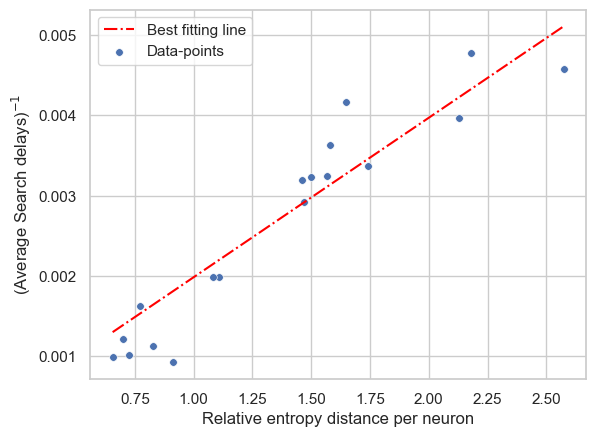

In [7]:
#calculating the slope (m)
slope_relative_entropy = (sum(relative_entropy_distances * (1/average_search_delays))) / sum(relative_entropy_distances**2)
print( f"Slope: {slope_relative_entropy}")

#Plotting the data-points and the fitting curve
y_fit = relative_entropy_distances * slope_relative_entropy
# sns.set_theme(palette="viridis", style="whitegrid")
sns.lineplot(x=relative_entropy_distances, y=y_fit, color="red", label="Best fitting line", linestyle="-.")
sns.scatterplot(x=relative_entropy_distances, y=1/average_search_delays, label="Data-points", s=30)
plt.legend()
plt.grid(True)
plt.xlabel("Relative entropy distance per neuron")
plt.ylabel("(Average Search delays)$^{-1}$")
plt.show()

#### (b) Fitting $y=mx$ to $l_1$ distance per neuron and  inverse of average search delays

In [8]:
#calculating the slope(m)
slope_l1 = (sum(L_1_distances * (1/average_search_delays))) / sum(L_1_distances**2)
print( f"Slope : {slope_l1}")

#Plotting the data-points and the fitting curve
y_fit = L_1_distances * slope_l1
sns.lineplot(L_1_distances, y_fit, color="red", label="Best fitting line")
sns.scatterplot(L_1_distances, 1/average_search_delays, label="Data-points", s=30)
plt.legend()
plt.grid()
plt.xlabel("$l_1$ distance per neuron")
plt.ylabel("(Average Search delays)$^{-1}$")
plt.show()

Slope : 0.0007000776902229354


TypeError: lineplot() takes from 0 to 1 positional arguments but 2 were given

It is clear from the graphs that the line in the case of relative entropy distafnces is a better fit.<br>
For mathematical validation, we will calculate the mean-squared error for both the case and compare them.


In [ ]:
mse_relative_entropy = (1/len(average_search_delays)) * (sum((slope_relative_entropy*relative_entropy_distances - 1/average_search_delays)**2))
mse_l1_distance = (1/len(average_search_delays)) * (sum((slope_l1*L_1_distances - 1/average_search_delays)**2))

print(f"MSE for Relative entropy distance per neuron : {mse_relative_entropy}")
print(f"MSE for l_1 distances per neuron: {mse_l1_distance}")

Mathematically also, relative entropy distance gives a better fit as its mean square error is apprximately 3 times lesser than that of L1 distance.

### 3. Fitting a Gamma distribution to the search delays.

#### (a) For this part, first we will start by randomly selecting half of the columns. For selection of columns I am using `np.random` with seed = 15 (my roll number) for easy reproduction of the outputs.

In [ ]:
#setting the seeed
np.random.seed(15)

#randomly selecting the seed
selected_indices = np.random.choice(18, 9,replace=False)
selected_indices.sort()
print(f"Selected indices are {selected_indices}")

Now, we will calculate and store the mean and standard deviation of each column.

In [ ]:
mean_search_delays = np.zeros(9)
std_search_delays = np.zeros(9)

for i in range(0,9):
    #getting the column
    column = search_times_df.iloc[2:, selected_indices[i]].copy()
    
    #resetting the indices of the column
    column = column.reset_index(drop=True)

    #subtracting the baseline reaction time of human
    column = column - 328

    #calculating the mean and standard deviation
    mean_search_delays[i] = column.mean()
    std_search_delays[i] = np.std(column)

Plotting the graphs and calculating the best fit slope

In [ ]:
## using the same formula -b/2a as before
slope = (sum(mean_search_delays * std_search_delays) / sum(mean_search_delays**2))
print(f"The estimated slope is {slope}")

#plotting
sns.lineplot(mean_search_delays, mean_search_delays*slope, linestyle="--", color = "red", label="Best fit line")
sns.scatterplot(mean_search_delays, std_search_delays, color="blue", label="Data points")
plt.legend()
plt.grid()
plt.xlabel("Mean search delay")
plt.ylabel("Standard Deviation")
plt.show()

For gamma distribution, we have $\mu = a/b$ and $\sigma = \sqrt{a}/b$, so the slope $m$ of the above graph is $\sigma / \mu = 1/\sqrt{a}$. So, $a = 1/m^2$. Using this relation, we estimate the shape parameter $a$

In [ ]:
shape_parameter = (1/slope)**2
print(f"The shape parameter a = {shape_parameter}")

#### (b) Now to estimate the rate parameter $b$, we will collect half samples from each of the unused column randommly and use them to estimate.


In [ ]:
#list consisting of the remaining indices
remaining_indices = [index for index in range(0,18) if index not in selected_indices]

Now we will make an array of samples by randomly taking one half values from each of the columns.

In [ ]:
#list to store the samples
samples_selected = [] #will be used for (b) to estimate rate parameter
samples_remaining =[] #will be ued for (c) part

for index in remaining_indices:
    #getting the column
    column = search_times_df.iloc[2:,index].copy().to_numpy()

    #subtracting the mean reaction time
    column = column - 328

    #shuffling the columns with a seed (for easy reproducability)
    np.random.seed(15+i)
    np.random.shuffle(column)

    mid_index = len(column)//2

    #selecting the first half samples, and putting the remaining ones for part (c)
    samples_selected.extend(column[:mid_index]) 
    samples_remaining.extend(column[mid_index:])

samples_selected = np.array(samples_selected)
samples_remaining = np.array(samples_remaining)

Now, we know that $\mu = a/b$, so $b= a / \mu$. <br>
Using this relation to calculate the rate parameter

In [ ]:
mean = np.mean(samples_selected)

rate_parameter = shape_parameter / mean
print(f"The estimated rate parameter b = {rate_parameter}")

#### (c) Now we will get the array `search_delays`

In [ ]:
#we will be using the remaining samples after part (b)
search_delays = samples_remaining

#now plotting the empirical CDF
search_delays = np.sort(search_delays)

#since the probability of each event is equal to 1/len(search_delays)
empirical_cdf = np.arange(1, len(search_delays)+1) / len(search_delays)
plt.step(search_delays, empirical_cdf, color = "red", label="Empirical CDF")

#now plotting the Gamma(a,b) CDF
x_gamma_cdf = np.linspace(search_delays[0],search_delays[-1],5000)
gamma_cdf = gamma.cdf(x_gamma_cdf,shape_parameter,scale = 1/rate_parameter)
sns.lineplot(x_gamma_cdf,gamma_cdf, color = "blue", linestyle="--", label=f"Gamma CDF (a={shape_parameter:.5f}, b={rate_parameter:.5f})")

plt.grid()
plt.xlabel("Search Delay")
plt.ylabel("Cumulative Probability")
plt.title("Empirical vs. Estimated CDF")
plt.legend()
plt.show()

The graph clearly shows that the data of the search delays fit very well to a gamma distribution. <br>
Now lets calculate and print the <i>Kolmogorov-Smirnov</i> test statistic given as 
$$\text{KS}(F,G) = \max_x |F(x)-G(x)|$$

In [ ]:
KS_test_stat = 0

#as indicated, looping for all x in search_delays
for i in range(len(search_delays)):
    x = search_delays[i]

    #F(x) is simply the emirical_cdf at this point
    F = empirical_cdf[i]

    #G(x) can be calculated using the scipy.stats import
    G = gamma.cdf(x, shape_parameter, scale = 1/rate_parameter)

    #updating max_diff (if bigger difference is found)
    KS_test_stat = max(KS_test_stat, abs(F-G))
print(f"The Kolmogorov-Smirnov test statistic for the search delays and theoretical Gamma distribution = {KS_test_stat:.6f}")